# Museum Heist -- PG-2

This is the **Reinforcement Learning** project developed during Erasmus exchange at the University of Milan.
The project focuses on stochastic policies and policy gradient, and its scientific objective
is to investigate the challenges related to strategic environments that require the use of stochastic policies.

The information below is just a small debrief of the task.
For more detailed task description please refer to the **README.md** file or **rl-project-report.pdf** in this repository.

## Problem Description

A thief is trying to steal a specific painting from an art museum.

A security camera is located in the correspondence of each exhibition room,
but the security guard in the control room can only watch one video feed at a time.
Once per round, an algorithm selects the next location to show on the screen.

Simultaneously, the thief **can move to a nearby room** or **stay in the same room**.
The thief starts from an unknown initial room, has to reach an unknown target room
(the one with the painting they want to steal) and go back to the initial room in order to escape.
The thief has a map of the museum and is also in radio contact with a hacker who knows the current active security camera.

The episode ends if:
- the surveillance algorithm selects the room currently occupied by the thief,
- thief escapes with the painting (select the target room after the painting has been stolen, but the thief has already escaped).

In [97]:
# imports
import gymnasium as gym
from gymnasium import spaces

from utils import *

## Environment and Thief

We model our Museum Environment as custom Reinforcement Learning environment using the **Gymnasium** framework.
This allows us to cleanly and easily separate the stateless nature of the surveillance Agent
from a little bit more complex, stateful mechanics of our Adversary (Thief) and the Museum state -- starting/painting position selection.
Environment itself needs to track everything to run the simulation, allow the Thief to move accordingly and provide rewards.

Since the agent is strictly stateless, environment's observation space is trivial (always returning 0), which forces the Agent to learn a generalized,
stochastic probability distribution rather than reacting to environment's live state changes.

### Museum topology

Museum is modeled as graph with vertices organized into n $\cdot$ m 2D grid, where each vertex is connected to at most 4 other neighboring vertices.
Most of the work of modeling input museum map into the 2D graph is done by the external _networkx_ library.

The environment has been extended with a possibility to parse custom maps with walls inside it (museum not necessarily have n $\cdot$ m rooms).
Additionally, we've included the possibility (for further training and evaluation) to allow different types of starting/painting position choosing.
The idea of just **random** sampling starting/painting position has been extended to also allow **fixed** positioning and **divided** positioning
(in which, we split the museum to left-right parts and randomly choose starting position always on the left side and painting position always on the right side).

We pass during environment's creating the museum topology map (with free rooms and walls) for the environment to parse it.
This solution is easily extendable to allow any other constraints (such as some fixed Thief or Painting positioning).

### Adversary (Thief)

While the agent is "blind", the environment secretly tracks all state metadata required to run the simulation
(to also satisfy the requirement, that Thief has a map and is in communication with the Hacker outside the museum):
the thief's position, the painting's location, possession status, and the _n_counts_ array
(which tracks how many rounds have passed since a room was last observed).


In [98]:
class MuseumHeistEnv(gym.Env):
    def __init__(self, museum_map, layout: SpawnStrategy = SpawnStrategy.RANDOM, b=2.0):
        # Initialize the learning environment.
        super().__init__()

        # Environmental metadata.
        self.beta = b
        self.museum_map = museum_map
        self.height = len(museum_map)
        self.width = len(museum_map[0])
        self.museum_layout = layout

        # Museum 2D grid topology, where graph nodes are denoted by (x, y).
        # Map each graph node (x, y) to integer from 0 to N-1 and vice versa to represent room numbers.
        self.museum_graph, self.num_rooms = map_museum_to_graph(museum_map)
        self.node_to_idx = {n: i for i, n in enumerate(self.museum_graph.nodes())}
        self.idx_to_node = {i: n for n, i in self.node_to_idx.items()}

        # Gym spaces -- Action (room selection) & Observation space for the agent.
        # Since policy is stochastic, the observation always returns 0 anyway (stateless).
        self.action_space = spaces.Discrete(self.num_rooms)
        self.observation_space = spaces.Discrete(1)

        # Internal state variables for cost calculation and episode finish.
        # n_counts represents for each room, the number of rounds since i-th room was last selected by surveillance algorithm.
        # Cost to enter room i-th is 1 + self.beta * 2 ^ { -(n_counts[i] - 1) }
        self.n_counts = np.ones(self.num_rooms)
        self.thief_pos = None
        self.painting_pos = None
        self.start_pos = None
        self.has_painting = False

    def reset(self, seed=None, options=None):
        # Restart the environment after episode finishes.
        super().reset(seed=seed)

        if self.museum_layout == SpawnStrategy.FIXED:
            # Fix the scenario: e.g., Enter bottom-left, steal from top-right
            self.start_pos = self.node_to_idx[(0, self.height-1)]
            self.painting_pos = self.node_to_idx[(self.width-1, 0)]

        elif self.museum_layout == SpawnStrategy.DIVIDED:
            # Filter valid rooms into "Left" and "Right" sides (node[0] is the x-coordinate)
            left_side_rooms = [node for node in self.museum_graph.nodes() if node[0] < self.width // 2]
            right_side_rooms = [node for node in self.museum_graph.nodes() if node[0] > self.width // 2]
            start_node = left_side_rooms[self.np_random.choice(len(left_side_rooms))]
            target_node = right_side_rooms[self.np_random.choice(len(right_side_rooms))]
            self.start_pos = self.node_to_idx[start_node]
            self.painting_pos = self.node_to_idx[target_node]

        else: # SpawnStrategy.RANDOM
            # Choose Thief starting position and painting position at random at the beginning of each episode.
            # Choose two at once with replace=False to avoid duplicating the same position.
            positions = self.np_random.choice(self.num_rooms, 2, replace=False)
            self.start_pos = positions[0]
            self.painting_pos = positions[1]

        # Initialize episode metadata at each reset and return (nothing, as Agent is stateless).
        self.thief_pos = self.start_pos
        self.has_painting = False
        self.n_counts = np.ones(self.num_rooms)
        return 0, {}

    def _calculate_next_thief_step(self, active_camera):
        # Perform one step of Thief in the museum topology.
        # Since Thief next move is state/environmental-dependant based on dynamic cost,
        # we calculate the shortest path inside it and return next step on Thief's path.

        # Museum graph has to be a DIRECTED graph, since the cost of entering i-th room
        # from j-th room can be different from entering j-th room from i-th room, since n_counts[i] != n_counts[j].
        # m_graph is the graph with current state/costs of entering each room.
        # For every edge in the initial Museum Map, calculate both edges of entering u and v.
        m_graph = nx.DiGraph()
        for u, v in self.museum_graph.edges():
            u_idx, v_idx = self.node_to_idx[u], self.node_to_idx[v]

            # First direction
            cost_v = 1.0 + self.beta * (2.0 ** -(self.n_counts[v_idx] - 1))
            m_graph.add_edge(u_idx, v_idx, weight=cost_v)

            # Second direction
            cost_u = 1.0 + self.beta * (2.0 ** -(self.n_counts[u_idx] - 1))
            m_graph.add_edge(v_idx, u_idx, weight=cost_u)

        # Hacker intervention (remove the possibility to move to the node currently surveilled).
        if active_camera in m_graph.nodes and active_camera != self.thief_pos:
            m_graph.remove_node(active_camera)

        current_target_room = self.start_pos if self.has_painting else self.painting_pos

        try:
            path = nx.shortest_path(m_graph, source=self.thief_pos, target=current_target_room, weight='weight')
            # If the Thief is not standing in the node that source == target.
            # Take the next step on the shortest path, path[0] is the source.
            return path[1] if len(path) > 1 else self.thief_pos
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            # If the only move possibility is blocked by the camera, enforce the Thief to stay in the same room.
            # If NodeNotFound (removed, as Hacker told him that camera is currently in the room he wants to reach), also stay in the same place.
            return self.thief_pos

    def step(self, a):
        # Perform one step of the environment (Thief movement, surveillance action).
        # Return is a tuple (observation -- 0 since stateless, reward, terminate, truncated, info)

        # 1. Update surveillance counters
        self.n_counts += 1
        self.n_counts[a] = 1

        # 2. Check whether Agent caught the Thief, reward if so.
        # Chosen room is the action fed into function (action taken by the agent).
        if a == self.thief_pos:
            return 0, 1.0, True, False, {"reason": "thief caught"}

        # 3. If Thief was not caught, move him to next position with already updated n_counts.
        # As Thief is in communication with a Hacker, that knows the currently active camera,
        # communicate it to the Thief, so he doesn't enter that room.
        self.thief_pos = self._calculate_next_thief_step(active_camera=a)

        # 4. Verify whether Thief is in the painting's room.
        if not self.has_painting and self.thief_pos == self.painting_pos:
            self.has_painting = True

        # 5. Check whether Agent let the Thief escape with the painting, reward accordingly.
        if self.has_painting and self.thief_pos == self.start_pos:
            return 0, -1.0, True, False, {"reason": "thief escaped"}

        # Episode continues
        return 0, 0.0, False, False, {}

## The Security Camera Agent (Stateless Softmax Policy Gradient)

We model the Security Camera as a Stateless REINFORCE Agent (Monte Carlo Policy Gradient).
Because the camera does not receive continuous observations about the Thief’s location, the problem reduces to learning a single,
generalized probability distribution over the available rooms (which maximizes the Thief's catching).

### Softmax Policy Gradient

The Agent's learning is represented by a parameter vector $\theta$, where each room (action) is assigned a single parameter initialized to zero.
To convert (learn) these raw parameters into a valid probability distribution, we use the **Softmax function** with a temperature parameter $\tau$:

<center>
$\pi_{\theta}(a) = Softmax(\frac{\theta_a}{\tau}) = \frac{exp(\frac{\theta_a}{\tau})}{\Sigma_{a' \in \mathcal{A}} exp(\frac{\theta_a'}{\tau})}$
</center>

Additionally, we provide the numerical stability by subtracting the maximum logit value before exponentiation to prevent overflow errors,
as $\theta$ might grow large throughout the learning process.

$\tau$ parameter is a **scalar temperature** that scales the logits. Higher temperature forces the distribution to remain flatter,
encouraging continuous exploration and preventing the policy from prematurely collapsing onto a single room, just because at some point, somewhere
the Agent got lucky and caught the Thief.

Because the environment requires a stochastic strategy, the _select_action_ method does not simply pick the room with the highest $\theta$ value.
Instead, it samples from the **Softmax probability distribution**. This ensures the Agent remains unpredictable to the Adversary,
while still favoring rooms with historically higher rewards.

### Learning Mechanism (REINFORCE)

The _update_ method performs the actual learning at the end of every episode using the **Policy Gradient Theorem**.

We introduce a few classical REINFORCE concepts in the _update_ method:
- **discounted returns**: the Agent first processes the episodic trajectory backwards to calculate the discounted future return for every action taken,
where $\gamma$ is the discount factor, which enforces that the action taken at moment i-th is a little more valuable, than previous actions
that led to that given action.
- **gradient ascent**: for each step in the trajectory, the Agent calculates the exact analytical gradient of the log-softmax policy and then updates
the parameter vector $\theta$ via $\theta_{k+1} = \theta_k + \alpha \cdot \nabla_\theta J(\theta_k) =
\theta_k + \alpha \cdot \nabla_\theta \ log \ \pi_\theta(a) \ R(\tau)$
- **variance reduction (baseline)**: vanilla REINFORCE can have kind of high variance. We introduce an optional baseline mechanism (use_baseline).
When enabled, the mean return of the episode is subtracted from each step's return. This centers the rewards—penalizing below-average actions and rewarding above-average ones, which might allow us to converge faster and more stable

We additionally have the adjustable **learning rate** $\alpha$, that controls how much the Agent adjusts its internal parameters in response to
estimated errors during training. It dictates how fast or slow a model learns, acting as a "step size".

In [99]:
class StatelessSoftmaxAgent:
    def __init__(self, num_rooms, t=1.0, learning_rate=0.05):
        # Policy hyperparameters
        self.theta = np.zeros(num_rooms)
        self.tau = t
        self.lr = learning_rate
        self.num_rooms = num_rooms

    def get_probabilities(self):
        # Calculations as in the lecture notes related Finite Horizon PG.
        logits = self.theta / self.tau
        logits -= np.max(logits)    # Numerical stability for Softmax
        exp_logits = np.exp(logits)
        return exp_logits / np.sum(exp_logits)

    def select_action(self):
        # Actions are sampled based on pi_theta(a) ~ exp(theta_a / tau)
        probs = self.get_probabilities()
        return np.random.choice(self.num_rooms, p=probs)

    def update(self, traj, use_baseline=False, g=0.99):
        # Since Agent is stateless, given input trajectory is just a list of (action, reward) tuples.
        probs = self.get_probabilities()

        # The gradient update for θ will rely solely on the score function (log derivative) of the softmax policy.
        # Use gradients multiplied by the Return (or expected Return) to update θ via gradient ascent.

        # Compute returns for each (future) step with discount factor gamma.
        returns = []
        total_future_reward = 0
        for _, r in reversed(traj):
            total_future_reward = r + g * total_future_reward
            returns.append(total_future_reward)

        # Introduce a baseline to REINFORCE update, as possible input parameter, to test and compare the performance.
        returns = np.array(returns)[::-1]
        if use_baseline: returns = returns - np.mean(returns)

        # Update theta parameters using REINFORCE (Policy Gradient Theorem).
        # Compute gradient of log pi and then the gradient ascent.
        for t, (a, _) in enumerate(traj):
            grad_log_pi = -probs.copy() / self.tau
            grad_log_pi[a] += 1.0 / self.tau
            self.theta = self.theta + self.lr * (grad_log_pi * returns[t])

## Training the agent

This section of the code represents the core Training Loop, where the StatelessSoftmaxAgent interacts with the MuseumHeistEnv over thousands
of simulated episodes to iteratively improve its policy.

Because REINFORCE is a Monte Carlo method, the agent must experience an entire episode from start to finish before it can learn anything.
Inside the learning loop, the Agent chooses the action to perform (room to surveil) and reports it to the environment until the episode has terminated.
We actively track the amount of wins the Agent has achieved during training process to monitor whether he's actually learning something.

Once the episode terminates (either the thief is caught or escapes), the inner loop breaks.
We then pass the complete trajectory list to the agent.update() method, where the Agent calculates the discounted returns for that specific heist
and adjusts its parameter vector $\theta$ via Gradient Ascent to make the successful actions more likely in the future.

We actively track the Agent's learning performance and later print it out with eye-pleasing plot with learning curve.
The plots, other performance test and comparisons for different hyperparameters are further discussed in the report.

### Hyperparameters

As mentioned before, we introduce a few adjustable hyperparameters, for further performance/convergence/learning curves evaluations.
Hyperparameters tweak includes establishing a **custom museum topology** and **layout of starting and painting positions**,
choosing the **number of training episodes**, a **discount factor** $\gamma$, an Adversary **"prudence" constant** $\beta$,
a **Softmax temperature** $\tau$, a **learning rate** $\alpha$ and setting whether to use **variance reduction** or not.

In [100]:
# Training metadata
custom_map = [
    "OOOOO",
    "OOWOO",
    "OOOOO",
    "OOWOO",
    "OOWOO",
]

custom_map1 = [
    "OOOOO",
    "OOOOO",
    "OOOOO",
    "OOOOO",
    "OOOOO",
]

custom_map2 = [
    "OOOOO",
]

custom_map3 = [
    "OOOOO",
    "OOWOO",
]

museum_layout = SpawnStrategy.DIVIDED
episodes = 5000

gamma = 0.99
lr = 0.05

beta = 2.0
temperature = 1.0

baseline = False

env = MuseumHeistEnv(museum_map=custom_map, layout=museum_layout, b=beta)
agent = StatelessSoftmaxAgent(num_rooms=env.num_rooms, t=temperature, learning_rate=lr)

In [101]:
print("\n--- Training ---\n")
win_rate_history = []
training_wins = 0

for ep in range(episodes):
    obs, _ = env.reset()
    done = False
    trajectory = []

    while not done:
        action = agent.select_action()
        _, reward, terminated, truncated, _ = env.step(action)
        trajectory.append((action, reward))
        done = terminated or truncated

        if float(reward) > 0: training_wins += 1

    agent.update(trajectory, use_baseline=baseline, g=gamma)

    # Track Agent's learning performance (winrate).
    if (ep + 1) % 100 == 0:
        win_rate = training_wins / 100.0
        win_rate_history.append(win_rate)
        print(f"Episode {ep+1} | Win Rate (last 100 rounds): {win_rate*100:.1f}%")
        training_wins = 0

# Print museum layout as numeric values.
final_probs = agent.get_probabilities()
print("\nFinal Policy Action Distribution (with -1 for walls):")

full_grid = np.full((env.height, env.width), -1.0)
for idx, prob in enumerate(final_probs):
    x, y = env.idx_to_node[idx]
    full_grid[y, x] = prob

print(np.round(full_grid, 3))

Episode 4600 | Win Rate (last 100 rounds): 69.0%
Episode 4700 | Win Rate (last 100 rounds): 65.0%
Episode 4800 | Win Rate (last 100 rounds): 71.0%
Episode 4900 | Win Rate (last 100 rounds): 73.0%
Episode 5000 | Win Rate (last 100 rounds): 74.0%

Final Policy Action Distribution (with -1 for walls):
[[ 0.001  0.013  0.419  0.052  0.001]
 [ 0.001  0.002 -1.     0.001  0.001]
 [ 0.002  0.078  0.353  0.068  0.002]
 [ 0.001  0.001 -1.     0.001  0.001]
 [ 0.001  0.001 -1.     0.001  0.   ]]


## Evaluating the Agent

Simple as that, when we already have trained Agent, we push out the update from the main loop and put inside the counter for amount of wins,
he scores during evaluation (putting trained agent on new museums without any updates on his side).

We track Agent's performance during _eval_episodes_ amount of episodes and at the end calculate, on average,
how many steps does it for the Thief to escape with the painting / the Agent to catch the Thief.

Since it's pretty important to know what the Agent has learned and which rooms he decided are the most important for a given museum layout
to observe to actually catch the Thief, we finalize the evaluation with another eye-pleasing heatmap.
The heatmap informs us about the importance of each graph's node/museum's room (selection probability distribution).
The higher the value inside given room, the more important it is to observe that room, as if we do, it's highly probable that we catch the Thief.

Further heatmap, experiments and analysis are moved inside the report file, so please refer to that.

In [102]:
print("\n--- Evaluation ---\n")
eval_episodes = 1000
eval_wins = 0
eval_total_steps = 0

# Freeze the Agent, stop updating it, just count the number of wins.
for ep in range(eval_episodes):
    obs, _ = env.reset()
    done = False
    steps = 0

    while not done:
        action = agent.select_action()
        _, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        steps += 1

        if float(reward) > 0:
            eval_wins += 1

    eval_total_steps += steps

eval_win_rate = (eval_wins / eval_episodes) * 100
avg_steps = eval_total_steps / eval_episodes

print(f"Evaluation Win Rate (over {eval_episodes} heists): {eval_win_rate:.1f}%")
print(f"Average steps to catch/escape: {avg_steps:.1f} steps")


--- Evaluation ---

Evaluation Win Rate (over 1000 heists): 76.3%
Average steps to catch/escape: 9.3 steps


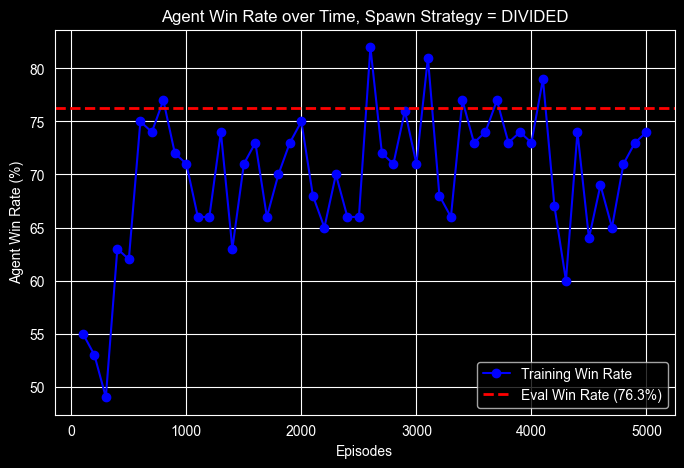

In [103]:
plot_learning_curve(win_rate_history, museum_layout, eval_win_rate)

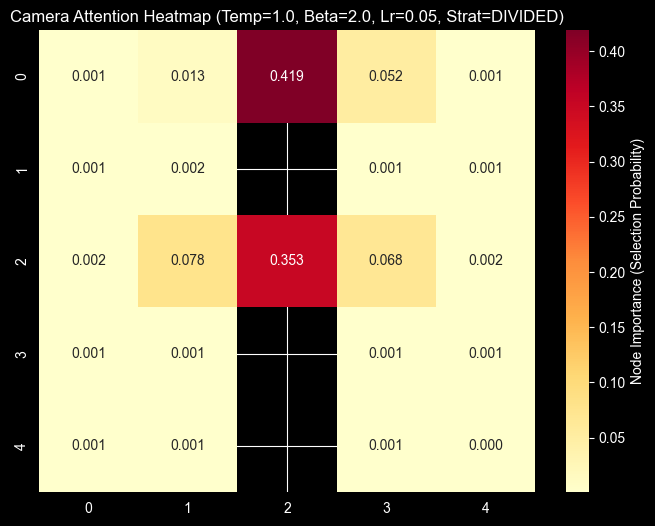

In [104]:
plot_museum_heatmap(env, agent, museum_layout)